# Imports & Configuration

In [ ]:
!pip install quadprog

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 534.6/534.6 kB 16.4 MB/s eta 0:00:00


In [ ]:
import os
import pickle
import random
import tarfile
import urllib.request
import numpy as np
import quadprog
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns

CIFAR10_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
DATA_DIR = "./cifar10_data"
PNG_DIR  = "./cifar10_pngs_full"

TRAIN_IMAGES_PER_CLASS = 3500
VAL_IMAGES_PER_CLASS = 500
TEST_IMAGES_PER_CLASS = 1000
BATCH_SIZE = 256
SEED = 42
NUM_EPOCHS = 10

CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
NORMALIZE = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Processing

In [ ]:
class AddGaussianNoise:
    def __init__(self, mean: float = 0.0, std: float = 0.1):
        self.mean = mean
        self.std  = std

    def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
        return tensor + torch.randn_like(tensor) * self.std + self.mean

In [ ]:
class RandomRotate90:
    def __call__(self, img):
        angle = random.choice([90, 180, 270])
        return transforms.functional.rotate(img, angle)

In [ ]:
def get_domain_transform(domain: int):
    base = [transforms.ToTensor(), NORMALIZE]
    if domain == 1:
        return transforms.Compose(base)
    elif domain == 2:
        return transforms.Compose([
            RandomRotate90(),
            transforms.ToTensor(),
            NORMALIZE,
        ])
    elif domain == 3:
        return transforms.Compose([
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            NORMALIZE,
        ])
    elif domain == 4:
        return transforms.Compose(base + [AddGaussianNoise(mean=0.0, std=0.1)])
    else:
        raise ValueError("Invalid domain")

In [ ]:
class CIFARDomainDataset(Dataset):
    def __init__(self, samples: list, domain: int):
        self.samples   = samples
        self.transform = get_domain_transform(domain)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

In [ ]:
def prepare_data_splits():
    os.makedirs(DATA_DIR, exist_ok=True)
    tar_path = os.path.join(DATA_DIR, "cifar-10-python.tar.gz")
    if not os.path.exists(tar_path):
        urllib.request.urlretrieve(CIFAR10_URL, tar_path)

    extract_path = os.path.join(DATA_DIR, "cifar-10-batches-py")
    if not os.path.exists(extract_path):
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(DATA_DIR)

    train_images, train_labels, test_images, test_labels = [], [], [], []
    for i in range(1, 6):
        with open(os.path.join(extract_path, f"data_batch_{i}"), "rb") as f:
            entry = pickle.load(f, encoding="bytes")
        train_images.append(entry[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1))
        train_labels.extend(entry[b"labels"])

    with open(os.path.join(extract_path, "test_batch"), "rb") as f:
        entry = pickle.load(f, encoding="bytes")
    test_images.append(entry[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1))
    test_labels.extend(entry[b"labels"])

    train_images = np.concatenate(train_images, axis=0)
    test_images = np.concatenate(test_images, axis=0)

    if not os.path.exists(PNG_DIR):
        rng = np.random.default_rng(SEED)

        class_indices_train = {i: [] for i in range(10)}
        for idx, lbl in enumerate(train_labels):
            if len(class_indices_train[int(lbl)]) < (TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS):
                class_indices_train[int(lbl)].append(idx)

        for lbl, indices in class_indices_train.items():
            indices = np.array(indices)
            rng.shuffle(indices)

            train_idx = indices[:TRAIN_IMAGES_PER_CLASS]
            val_idx = indices[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS]

            for split_name, idx_list in [("train", train_idx), ("val", val_idx)]:
                class_dir = os.path.join(PNG_DIR, split_name, CIFAR10_CLASSES[lbl])
                os.makedirs(class_dir, exist_ok=True)
                for i, idx in enumerate(idx_list):
                    Image.fromarray(train_images[idx]).save(os.path.join(class_dir, f"{i:05d}.png"))

        test_counts = {i: 0 for i in range(10)}
        for img, lbl in zip(test_images, test_labels):
            if test_counts[int(lbl)] < TEST_IMAGES_PER_CLASS:
                class_dir = os.path.join(PNG_DIR, "test", CIFAR10_CLASSES[int(lbl)])
                os.makedirs(class_dir, exist_ok=True)
                Image.fromarray(img).save(os.path.join(class_dir, f"{test_counts[int(lbl)]:05d}.png"))
                test_counts[int(lbl)] += 1

    splits = {"train": [], "val": [], "test": []}
    for split_name in ["train", "val", "test"]:
        for lbl, cls in enumerate(CIFAR10_CLASSES):
            cls_dir = os.path.join(PNG_DIR, split_name, cls)
            if os.path.exists(cls_dir):
                files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.endswith(".png")]
                splits[split_name].extend([(p, lbl) for p in files])

    return splits

In [ ]:
def build_all_domains(splits, batch_size=BATCH_SIZE, num_workers=2):
    all_loaders = {}
    for domain in range(1, 5):
        loaders = {}
        for split_name in ["train", "val", "test"]:
            dataset = CIFARDomainDataset(splits[split_name], domain=domain)
            loaders[split_name] = DataLoader(dataset, batch_size=batch_size, shuffle=(split_name == "train"), num_workers=num_workers, pin_memory=True)
        all_loaders[domain] = loaders
    return all_loaders

# Model Architecture & Evaluation

The Gradient Episodic Memory (GEM) paper explicitly utilizes a ResNet-18 backbone for experiments on the CIFAR-100 dataset. It is the de facto standard for evaluating continual learning algorithms on small-resolution datasets, providing enough capacity to learn without severely overfitting the small memory buffers used in methods like GEM and PCGrad.

To prevent the spatial dimensions of the $32 \times 32$ images from collapsing too early in the network, the initial $7 \times 7$ convolutional layer is replaced with a $3 \times 3$ layer. The max-pooling layer is also replaced with an identity function.

In [ ]:
def get_cifar10_resnet18(num_classes=10):
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [ ]:
def visualize_domain_samples(loaders, classes):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    for domain in range(1, 5):
        x, y = next(iter(loaders[domain]["train"]))
        img_tensor = x[0].cpu()
        label = y[0].item()
        img_tensor = img_tensor * std + mean
        img_np = img_tensor.numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np, 0, 1)

        axes[domain-1].imshow(img_np)
        axes[domain-1].set_title(f"Domain {domain}\n{classes[label]}")
        axes[domain-1].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate(model, test_loaders, current_task_id, device):
    model.eval()
    accuracies = []

    with torch.no_grad():
        for t in range(current_task_id + 1):
            correct, total = 0, 0
            for x, y in test_loaders[t]:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

            accuracies.append(100 * correct / total if total > 0 else 0)

    return accuracies

In [ ]:
def calculate_metrics_and_visualize(accuracy_matrix, method_name):
    matrix = np.zeros((len(accuracy_matrix), len(accuracy_matrix)))
    for i, row in enumerate(accuracy_matrix):
        for j, acc in enumerate(row):
            matrix[i, j] = acc

    T = len(matrix)
    avg_accuracy = np.mean(matrix[T-1, :])

    bwt_sum = sum((matrix[T-1, j] - matrix[j, j]) for j in range(T - 1))
    backward_transfer = bwt_sum / (T - 1) if T > 1 else 0

    print(f"\n--- Final Metrics for {method_name} ---")
    print(f"Average Accuracy:  {avg_accuracy:.2f}%")
    print(f"Backward Transfer: {backward_transfer:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(matrix, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=[f"Test D{j+1}" for j in range(T)],
                yticklabels=[f"Train D{i+1}" for i in range(T)],
                ax=axes[0], mask=(matrix == 0))
    axes[0].set_title(f"{method_name}: Accuracy Matrix")

    metrics = ['Average Accuracy', 'Backward Transfer']
    values = [avg_accuracy, backward_transfer]
    colors = ['#4C72B0', '#C44E52' if backward_transfer < 0 else '#55A868']

    axes[1].bar(metrics, values, color=colors)
    axes[1].set_ylim(min(0, backward_transfer - 10), 100)
    axes[1].set_title(f"{method_name}: Final Performance")

    for i, v in enumerate(values):
        axes[1].text(i, v + (2 if v > 0 else -6), f"{v:.2f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Gradient Inteference Methods

In [ ]:
class OGD:
    def __init__(self, model, max_basis_size=200):
        self.model = model
        self.basis = []
        self.max_basis_size = max_basis_size
        self.device = next(model.parameters()).device

    def _get_flattened_gradients(self):
        grads = [param.grad.view(-1) for param in self.model.parameters() if param.grad is not None]
        return torch.cat(grads) if grads else torch.tensor([], device=self.device)

    def _set_flattened_gradients(self, flat_grads):
        offset = 0
        for param in self.model.parameters():
            if param.grad is not None:
                numel = param.numel()
                param.grad.copy_(flat_grads[offset:offset + numel].view(param.shape))
                offset += numel

    def project_gradients(self):
        if not self.basis:
            return
        g = self._get_flattened_gradients()
        for v in self.basis:
            dot_product = torch.dot(g, v)
            g = g - dot_product * v
        self._set_flattened_gradients(g)

    def update_basis(self, task_dataloader):
        self.model.eval()
        for x, y in task_dataloader:
            x, y = x.to(self.device), y.to(self.device)
            for i in range(x.size(0)):
                if len(self.basis) >= self.max_basis_size:
                    return
                self.model.zero_grad()
                logits = self.model(x[i:i+1])
                ground_truth_logit = logits[0, y[i]]
                ground_truth_logit.backward()
                u = self._get_flattened_gradients()
                for v in self.basis:
                    u = u - torch.dot(u, v) * v
                norm = torch.norm(u)
                if norm > 1e-5:
                    self.basis.append((u / norm).detach().clone())

In [ ]:
class GEM:
    def __init__(self, model, memory_budget=5120, gamma=0.1):
        self.model = model
        self.memory_budget = memory_budget
        self.gamma = gamma
        self.episodic_memory = {}
        self.device = next(model.parameters()).device

    def _get_flattened_gradients(self):
        grads = [param.grad.view(-1) for param in self.model.parameters() if param.grad is not None]
        return torch.cat(grads) if grads else torch.tensor([], device=self.device)

    def _set_flattened_gradients(self, flat_grads):
        offset = 0
        for param in self.model.parameters():
            if param.grad is not None:
                numel = param.numel()
                param.grad.copy_(flat_grads[offset:offset + numel].view(param.shape))
                offset += numel

    def project_gradients(self, current_task_id, current_loss_fn):
        if not self.episodic_memory:
            return
        g = self._get_flattened_gradients().detach().clone()
        past_task_grads = []
        for task_id, memory in self.episodic_memory.items():
            if task_id >= current_task_id:
                continue
            self.model.zero_grad()
            x_mem, y_mem = memory[0].to(self.device), memory[1].to(self.device)
            loss_k = current_loss_fn(self.model(x_mem), y_mem)
            loss_k.backward()
            past_task_grads.append(self._get_flattened_gradients().detach())

        if not past_task_grads:
            self._set_flattened_gradients(g)
            return

        G = torch.stack(past_task_grads)
        if (torch.mv(G, g) >= 0).all():
            self._set_flattened_gradients(g)
            return

        G_np, g_np = G.cpu().numpy(), g.cpu().numpy()
        P = np.dot(G_np, G_np.T) + self.gamma * np.eye(G_np.shape[0])
        q = np.dot(G_np, g_np)

        try:
            v_star = quadprog.solve_qp(P, -q, np.eye(P.shape[0]), np.zeros(P.shape[0]))[0]
        except ValueError:
            v_star = np.zeros(P.shape[0])

        v_star = torch.tensor(v_star, dtype=torch.float32, device=self.device)
        self._set_flattened_gradients(torch.mv(G.t(), v_star) + g)

    def update_memory(self, task_id, x_data, y_data):
        self.episodic_memory[task_id] = (x_data, y_data)

In [ ]:
class PCGrad:
    def __init__(self, model):
        self.model = model
        self.episodic_memory = []
        self.device = next(model.parameters()).device

    def _get_flattened_gradients(self):
        grads = [param.grad.view(-1) for param in self.model.parameters() if param.grad is not None]
        return torch.cat(grads) if grads else torch.tensor([], device=self.device)

    def _set_flattened_gradients(self, flat_grads):
        offset = 0
        for param in self.model.parameters():
            if param.grad is not None:
                numel = param.numel()
                param.grad.copy_(flat_grads[offset:offset + numel].view(param.shape))
                offset += numel

    def project_gradients(self, current_loss_fn):
        if not self.episodic_memory:
            return
        g_current = self._get_flattened_gradients().detach().clone()
        self.model.zero_grad()
        x_mem, y_mem = self.episodic_memory[0].to(self.device), self.episodic_memory[1].to(self.device)
        loss_replay = current_loss_fn(self.model(x_mem), y_mem)
        loss_replay.backward()
        g_replay = self._get_flattened_gradients().detach().clone()

        grads = [g_current, g_replay]
        projected_grads = []
        indices = [0, 1]
        random.shuffle(indices)

        for i in indices:
            g_i, g_j = grads[i].clone(), grads[1 - i]
            dot_product = torch.dot(g_i, g_j)
            if dot_product < 0:
                norm_sq = torch.dot(g_j, g_j)
                if norm_sq > 1e-8:
                    g_i = g_i - (dot_product / norm_sq) * g_j
            projected_grads.append(g_i)

        self._set_flattened_gradients(projected_grads[0] + projected_grads[1])

    def update_memory(self, x_data, y_data):
        if not self.episodic_memory:
            self.episodic_memory = [x_data, y_data]
        else:
            self.episodic_memory[0] = torch.cat([self.episodic_memory[0], x_data], dim=0)
            self.episodic_memory[1] = torch.cat([self.episodic_memory[1], y_data], dim=0)

# Data Generation & Visualization

/tmp/ipykernel_6119/290599283.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


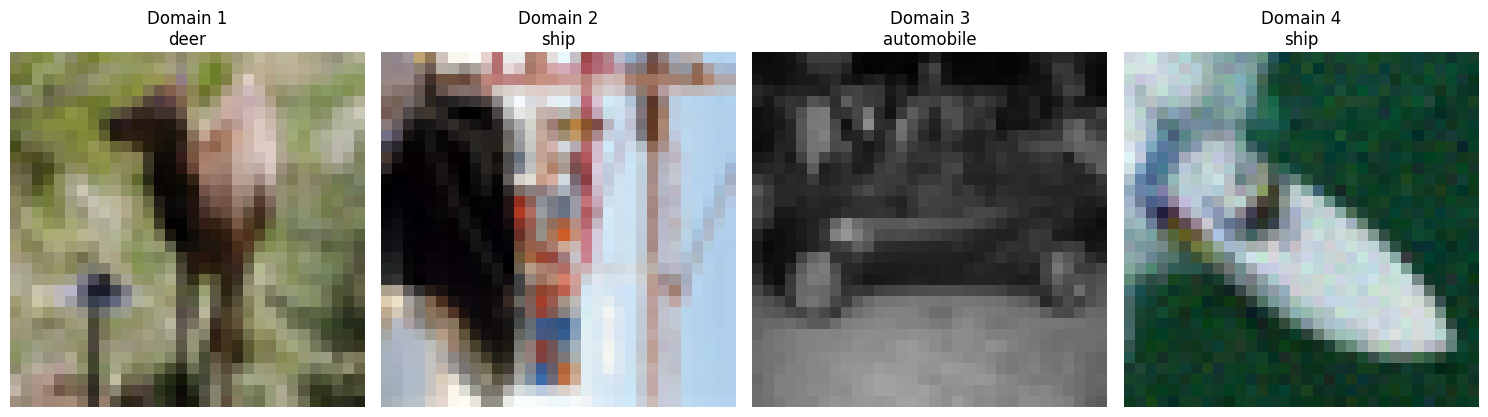

In [ ]:
splits = prepare_data_splits()
all_loaders = build_all_domains(splits, num_workers=2)

sequential_train_loaders = [all_loaders[domain]["train"] for domain in range(1, 5)]
sequential_val_loaders = [all_loaders[domain]["val"] for domain in range(1, 5)]
sequential_test_loaders = [all_loaders[domain]["test"] for domain in range(1, 5)]

visualize_domain_samples(all_loaders, CIFAR10_CLASSES)

# OGD Execution Loop


Starting Sequential Training with OGD...

--- Training on Domain 1 ---
   Epoch 1/10 - Loss: 1.7273
   Epoch 2/10 - Loss: 1.2394
   Epoch 3/10 - Loss: 0.8908
   Epoch 4/10 - Loss: 0.5990
   Epoch 5/10 - Loss: 0.4135
   Epoch 6/10 - Loss: 0.2462
   Epoch 7/10 - Loss: 0.1096
   Epoch 8/10 - Loss: 0.0247
   Epoch 9/10 - Loss: 0.0040
   Epoch 10/10 - Loss: 0.0017
   Validation Accuracy on Domain 1: 80.68%
   Test Accuracy on Domain 1: 80.97%

--- Training on Domain 2 ---
   Epoch 1/10 - Loss: 1.6206
   Epoch 2/10 - Loss: 0.9494
   Epoch 3/10 - Loss: 0.8560
   Epoch 4/10 - Loss: 0.7249
   Epoch 5/10 - Loss: 0.6186
   Epoch 6/10 - Loss: 0.5194
   Epoch 7/10 - Loss: 0.4146
   Epoch 8/10 - Loss: 0.3066
   Epoch 9/10 - Loss: 0.2108
   Epoch 10/10 - Loss: 0.1477
   Validation Accuracy on Domain 2: 79.28%
   Test Accuracy on Domain 1: 48.74%
   Test Accuracy on Domain 2: 79.49%

--- Training on Domain 3 ---
   Epoch 1/10 - Loss: 0.7532
   Epoch 2/10 - Loss: 0.2895
   Epoch 3/10 - Loss: 0.1423
  

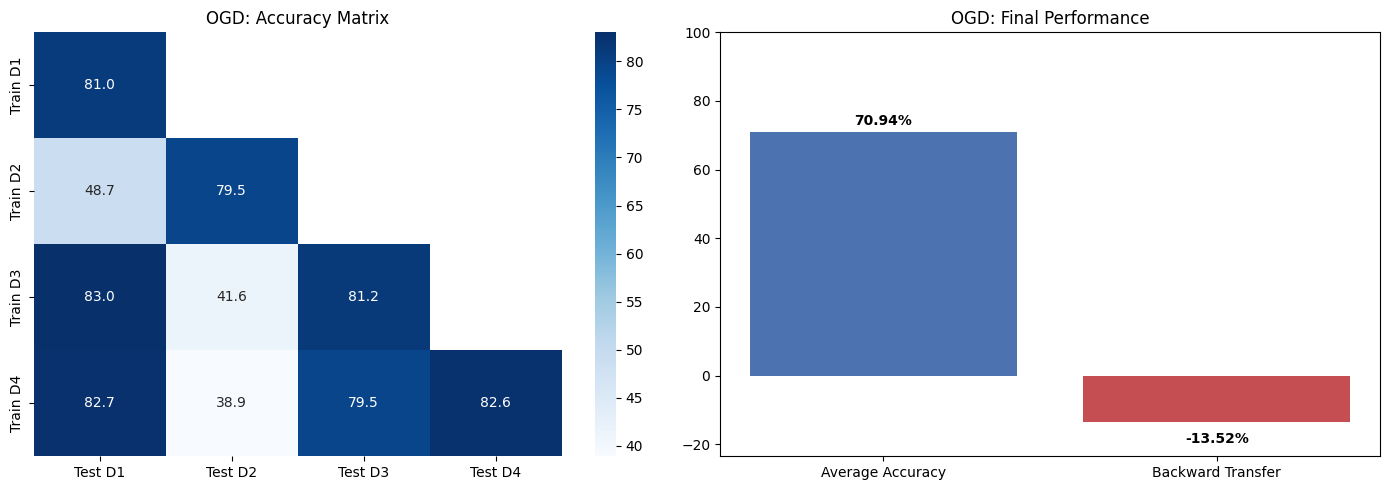

In [ ]:
print(f"\n{'='*50}")
print("Starting Sequential Training with OGD...")
print(f"{'='*50}")

model = get_cifar10_resnet18(num_classes=10).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()
method = OGD(model)

method_accuracy_matrix = []

for task_id, task_dataloader in enumerate(sequential_train_loaders):
    print(f"\n--- Training on Domain {task_id + 1} ---")

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=0.1,
        steps_per_epoch=len(task_dataloader),
        epochs=NUM_EPOCHS
    )

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        for batch_idx, (x, y) in enumerate(task_dataloader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            method.project_gradients()

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        print(f"   Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {running_loss / len(task_dataloader):.4f}")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x_val, y_val in sequential_val_loaders[task_id]:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            _, predicted = torch.max(outputs.data, 1)
            val_total += y_val.size(0)
            val_correct += (predicted == y_val).sum().item()

    val_acc = 100 * val_correct / val_total if val_total > 0 else 0
    print(f"   Validation Accuracy on Domain {task_id + 1}: {val_acc:.2f}%")

    method.update_basis(task_dataloader)

    task_accuracies = evaluate(model, sequential_test_loaders, task_id, device)
    method_accuracy_matrix.append(task_accuracies)

    for t, acc in enumerate(task_accuracies):
        print(f"   Test Accuracy on Domain {t + 1}: {acc:.2f}%")

calculate_metrics_and_visualize(method_accuracy_matrix, "OGD")

# GEM Execution Loop


Starting Sequential Training with GEM...

--- GEM Training on Domain 1 ---
   Epoch 1/10 - Loss: 1.7369
   Epoch 2/10 - Loss: 1.2863
   Epoch 3/10 - Loss: 0.8904
   Epoch 4/10 - Loss: 0.6709
   Epoch 5/10 - Loss: 0.4370
   Epoch 6/10 - Loss: 0.2358
   Epoch 7/10 - Loss: 0.1004
   Epoch 8/10 - Loss: 0.0243
   Epoch 9/10 - Loss: 0.0039
   Epoch 10/10 - Loss: 0.0018
   Validation Accuracy on Domain 1: 80.62%
   Test Accuracy on Domain 1: 81.18%

--- GEM Training on Domain 2 ---
   Epoch 1/10 - Loss: 1.5924
   Epoch 2/10 - Loss: 0.9656
   Epoch 3/10 - Loss: 0.8403
   Epoch 4/10 - Loss: 0.7227
   Epoch 5/10 - Loss: 0.6192
   Epoch 6/10 - Loss: 0.5138
   Epoch 7/10 - Loss: 0.4235
   Epoch 8/10 - Loss: 0.3147
   Epoch 9/10 - Loss: 0.2202
   Epoch 10/10 - Loss: 0.1502
   Validation Accuracy on Domain 2: 79.84%
   Test Accuracy on Domain 1: 50.05%
   Test Accuracy on Domain 2: 79.74%

--- GEM Training on Domain 3 ---
   Epoch 1/10 - Loss: 0.7607
   Epoch 2/10 - Loss: 0.3054
   Epoch 3/10 - Los

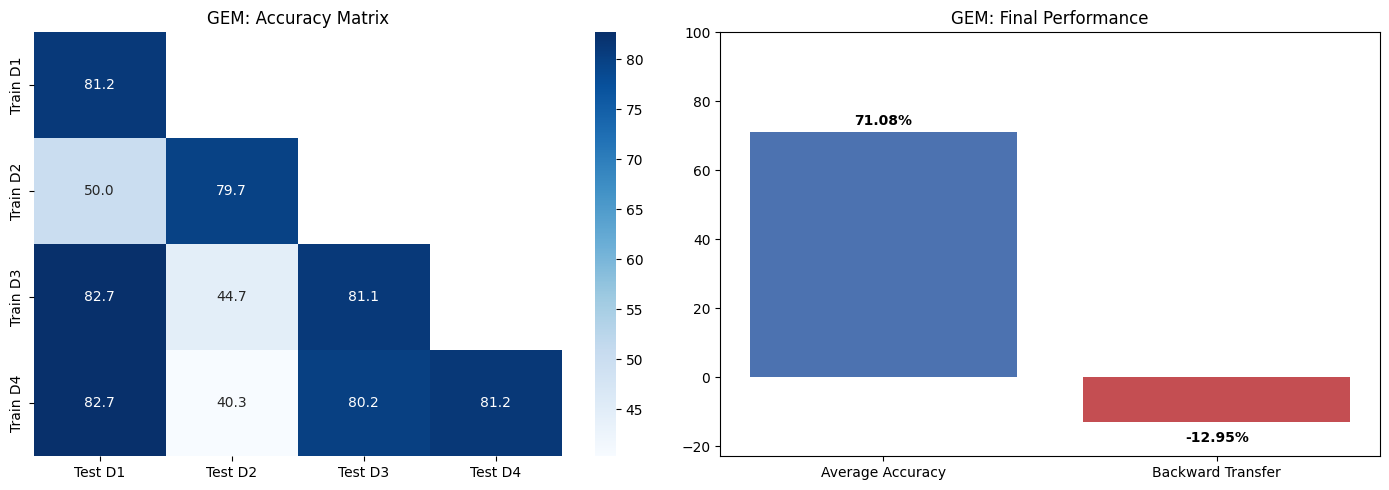

In [ ]:
print(f"\n{'='*50}")
print("Starting Sequential Training with GEM...")
print(f"{'='*50}")

model = get_cifar10_resnet18(num_classes=10).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()
method = GEM(model)
method_accuracy_matrix = []

for task_id, task_dataloader in enumerate(sequential_train_loaders):
    print(f"\n--- GEM Training on Domain {task_id + 1} ---")

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=0.1,
        steps_per_epoch=len(task_dataloader),
        epochs=NUM_EPOCHS
    )

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(task_dataloader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            method.project_gradients(task_id, loss_fn)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        print(f"   Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {running_loss / len(task_dataloader):.4f}")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x_val, y_val in sequential_val_loaders[task_id]:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            _, predicted = torch.max(outputs.data, 1)
            val_total += y_val.size(0)
            val_correct += (predicted == y_val).sum().item()

    val_acc = 100 * val_correct / val_total if val_total > 0 else 0
    print(f"   Validation Accuracy on Domain {task_id + 1}: {val_acc:.2f}%")

    mem_x, mem_y = next(iter(task_dataloader))
    method.update_memory(task_id, mem_x.to(device), mem_y.to(device))

    task_accuracies = evaluate(model, sequential_test_loaders, task_id, device)
    method_accuracy_matrix.append(task_accuracies)

    for t, acc in enumerate(task_accuracies):
        print(f"   Test Accuracy on Domain {t + 1}: {acc:.2f}%")

calculate_metrics_and_visualize(method_accuracy_matrix, "GEM")

# PCGrad Execution Loop


Starting Sequential Training with PCGrad...

--- PCGrad Training on Domain 1 ---
   Epoch 1/10 - Loss: 1.7358
   Epoch 2/10 - Loss: 1.2526
   Epoch 3/10 - Loss: 0.8927
   Epoch 4/10 - Loss: 0.6300
   Epoch 5/10 - Loss: 0.4103
   Epoch 6/10 - Loss: 0.2357
   Epoch 7/10 - Loss: 0.1032
   Epoch 8/10 - Loss: 0.0259
   Epoch 9/10 - Loss: 0.0038
   Epoch 10/10 - Loss: 0.0018
   Validation Accuracy on Domain 1: 80.70%
   Test Accuracy on Domain 1: 81.03%

--- PCGrad Training on Domain 2 ---
   Epoch 1/10 - Loss: 1.5801
   Epoch 2/10 - Loss: 0.9859
   Epoch 3/10 - Loss: 0.8483
   Epoch 4/10 - Loss: 0.6957
   Epoch 5/10 - Loss: 0.5907
   Epoch 6/10 - Loss: 0.4924
   Epoch 7/10 - Loss: 0.3998
   Epoch 8/10 - Loss: 0.2896
   Epoch 9/10 - Loss: 0.1950
   Epoch 10/10 - Loss: 0.1357
   Validation Accuracy on Domain 2: 78.60%
   Test Accuracy on Domain 1: 56.34%
   Test Accuracy on Domain 2: 78.02%

--- PCGrad Training on Domain 3 ---
   Epoch 1/10 - Loss: 0.7180
   Epoch 2/10 - Loss: 0.2785
   Epoc

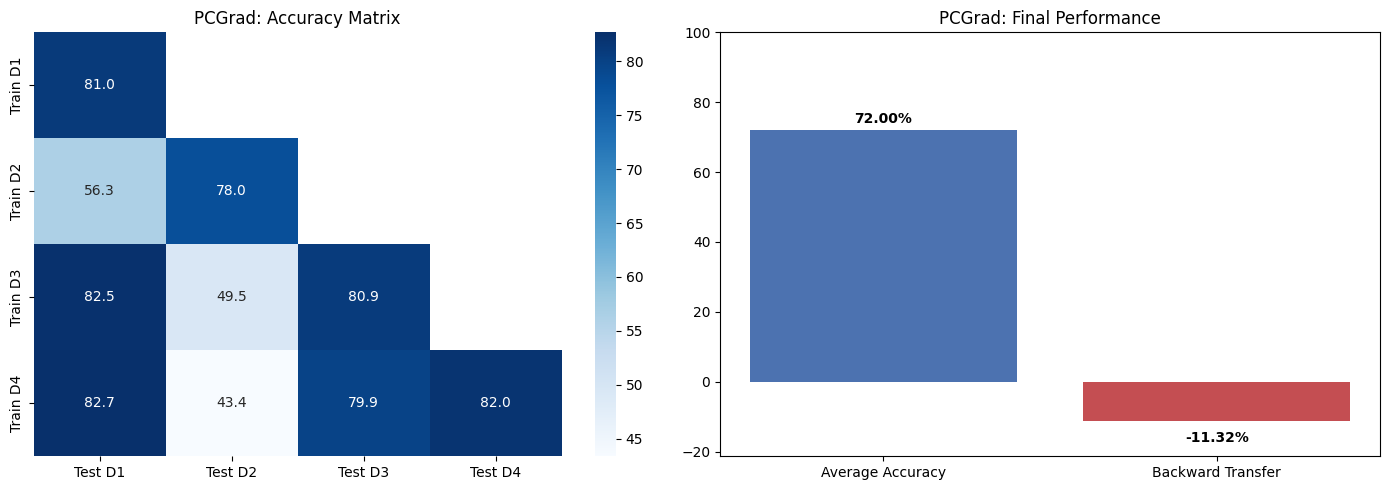

In [ ]:
print(f"\n{'='*50}")
print("Starting Sequential Training with PCGrad...")
print(f"{'='*50}")

model = get_cifar10_resnet18(num_classes=10).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()
method = PCGrad(model)
method_accuracy_matrix = []

for task_id, task_dataloader in enumerate(sequential_train_loaders):
    print(f"\n--- PCGrad Training on Domain {task_id + 1} ---")

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=0.1,
        steps_per_epoch=len(task_dataloader),
        epochs=NUM_EPOCHS
    )

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(task_dataloader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()

            method.project_gradients(loss_fn)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        print(f"   Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {running_loss / len(task_dataloader):.4f}")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x_val, y_val in sequential_val_loaders[task_id]:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            _, predicted = torch.max(outputs.data, 1)
            val_total += y_val.size(0)
            val_correct += (predicted == y_val).sum().item()

    val_acc = 100 * val_correct / val_total if val_total > 0 else 0
    print(f"   Validation Accuracy on Domain {task_id + 1}: {val_acc:.2f}%")

    mem_x, mem_y = next(iter(task_dataloader))
    method.update_memory(mem_x.to(device), mem_y.to(device))

    task_accuracies = evaluate(model, sequential_test_loaders, task_id, device)
    method_accuracy_matrix.append(task_accuracies)

    for t, acc in enumerate(task_accuracies):
        print(f"   Test Accuracy on Domain {t + 1}: {acc:.2f}%")

calculate_metrics_and_visualize(method_accuracy_matrix, "PCGrad")